# **Setup**

In [ ]:
!pip install tensorflow scikit-learn matplotlib numpy -q

from google.colab import drive
drive.mount('/content/drive')

print("Setup complete!")

Mounted at /content/drive
Setup complete!


# **Import Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

DRIVE_PATH = "/content/drive/MyDrive/lung-cancer-dataset"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DRIVE_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    classes=['Malignant cases', 'Normal cases']
)

val_data = val_datagen.flow_from_directory(
    DRIVE_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    classes=['Malignant cases', 'Normal cases']
)

print(f"✅ Training:   {train_data.samples} images")
print(f"✅ Validation: {val_data.samples} images")
print(f"✅ Classes:    {train_data.class_indices}")

TensorFlow version: 2.19.0
GPU available: True


# **LOAD DATASET**

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/lung-cancer-dataset"
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=['Malignant cases', 'Benign cases', 'Normal cases'],
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=['Malignant cases', 'Benign cases', 'Normal cases'],
    shuffle=False
)

print(f"\nTraining images   : {train_data.samples}")
print(f"Validation images : {val_data.samples}")
print(f"Classes           : {list(train_data.class_indices.keys())}")
print(f"Class indices     : {train_data.class_indices}")

Found 2888 images belonging to 3 classes.
Found 721 images belonging to 3 classes.

Training images   : 2888
Validation images : 721
Classes           : ['Malignant cases', 'Benign cases', 'Normal cases']
Class indices     : {'Malignant cases': 0, 'Benign cases': 1, 'Normal cases': 2}


# **Visualize Sample Images**

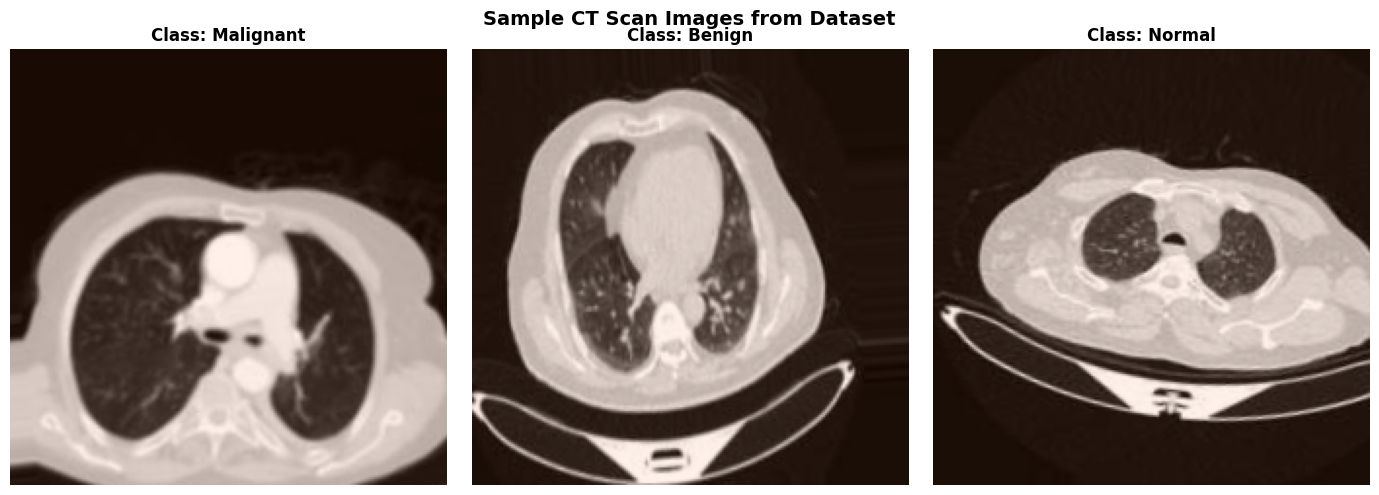

Sample images displayed successfully!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


images, labels = next(train_data)
class_names = ['Malignant', 'Benign', 'Normal']

plt.figure(figsize=(14, 5))
plt.suptitle('Sample CT Scan Images from Dataset',
             fontsize=14, fontweight='bold')


shown = {0: False, 1: False, 2: False}
plot_idx = 1

for i in range(len(images)):
    label_idx = np.argmax(labels[i])
    if not shown[label_idx] and plot_idx <= 3:
        plt.subplot(1, 3, plot_idx)
        img_display = images[i] - images[i].min()
        img_display = img_display / img_display.max()
        plt.imshow(img_display)
        plt.title(f'Class: {class_names[label_idx]}',
                  fontsize=12, fontweight='bold')
        plt.axis('off')
        shown[label_idx] = True
        plot_idx += 1
    if plot_idx > 3:
        break

plt.tight_layout()
plt.show()
print("Sample images displayed successfully!")

# **BUILD THE MODEL — ResNet50**

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)


x = layers.Dense(256, activation='relu')(x)


x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

print("Model Architecture:")
print(f"  Base model    : ResNet50 (pretrained on ImageNet)")
print(f"  Total layers  : {len(model.layers)}")
print(f"  Output classes: 3 (Malignant, Benign, Normal)")
print(f"  Parameters    : {model.count_params():,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model Architecture:
  Base model    : ResNet50 (pretrained on ImageNet)
  Total layers  : 6
  Output classes: 3 (Malignant, Benign, Normal)
  Parameters    : 24,113,027


# TRAIN THE **MODEL**

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training classification head (3 epochs)")
print("-" * 50)

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    verbose=1
)

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("\nPhase 2: Fine tuning full model (up to 15 epochs)")
print("-" * 50)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f"\nFinal Validation Accuracy : {val_acc*100:.2f}%")
print(f"Final Validation Loss     : {val_loss:.4f}")

Phase 1: Training classification head (3 epochs)
--------------------------------------------------
Epoch 1/3
91/91 ━━━━━━━━━━━━━━━━━━━━ 1267s 14s/step - accuracy: 0.6468 - loss: 0.8416 - val_accuracy: 0.7656 - val_loss: 0.4492
Epoch 2/3
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 572ms/step - accuracy: 0.7528 - loss: 0.5247 - val_accuracy: 0.7351 - val_loss: 0.5004
Epoch 3/3
91/91 ━━━━━━━━━━━━━━━━━━━━ 56s 615ms/step - accuracy: 0.7704 - loss: 0.4802 - val_accuracy: 0.7476 - val_loss: 0.4982

Phase 2: Fine tuning full model (up to 15 epochs)
--------------------------------------------------
Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 93s 760ms/step - accuracy: 0.7351 - loss: 0.6742 - val_accuracy: 0.6574 - val_loss: 0.8444
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 565ms/step - accuracy: 0.8234 - loss: 0.3921 - val_accuracy: 0.7309 - val_loss: 0.6107
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 54s 591ms/step - accuracy: 0.8566 - loss: 0.3331 - val_accuracy: 0.7809 - val_loss: 0.5572
Epoch 4/15
91/91 ━━━━━━━━━━

# **PLOT TRAINING RESULTS**

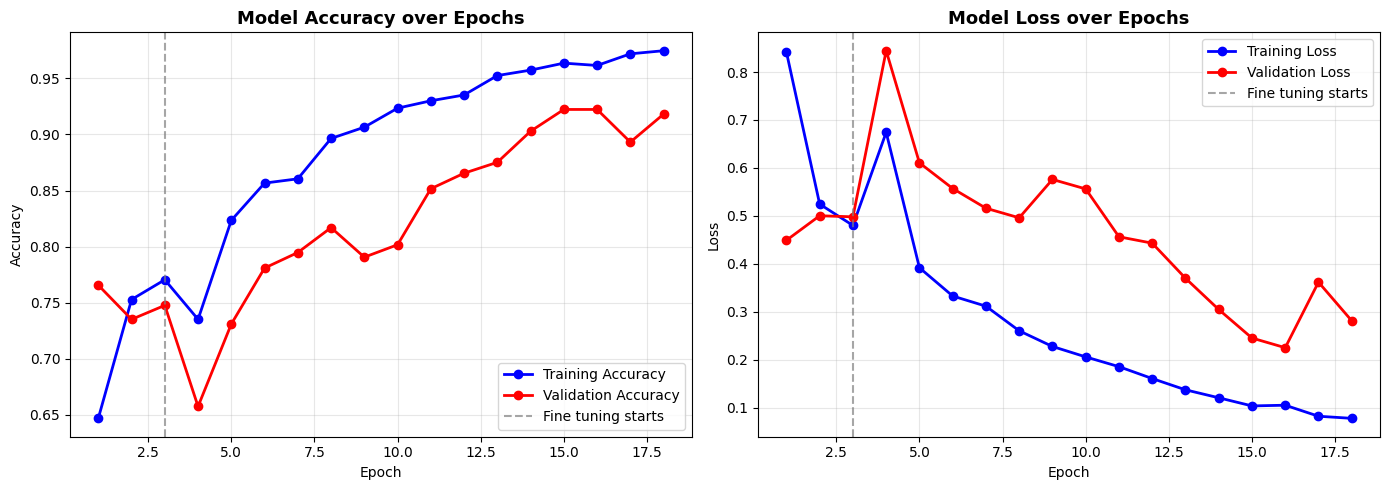

Training graphs saved to Drive!


In [ ]:
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
epochs  = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc,     'b-o', label='Training Accuracy',   linewidth=2)
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy', linewidth=2)
plt.axvline(x=3, color='gray', linestyle='--',
            label='Fine tuning starts', alpha=0.7)
plt.title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     'b-o', label='Training Loss',   linewidth=2)
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss', linewidth=2)
plt.axvline(x=3, color='gray', linestyle='--',
            label='Fine tuning starts', alpha=0.7)
plt.title('Model Loss over Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung-cancer-dataset/training_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Training graphs saved to Drive!")

# **DETAILED EVALUATION**

23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 391ms/step


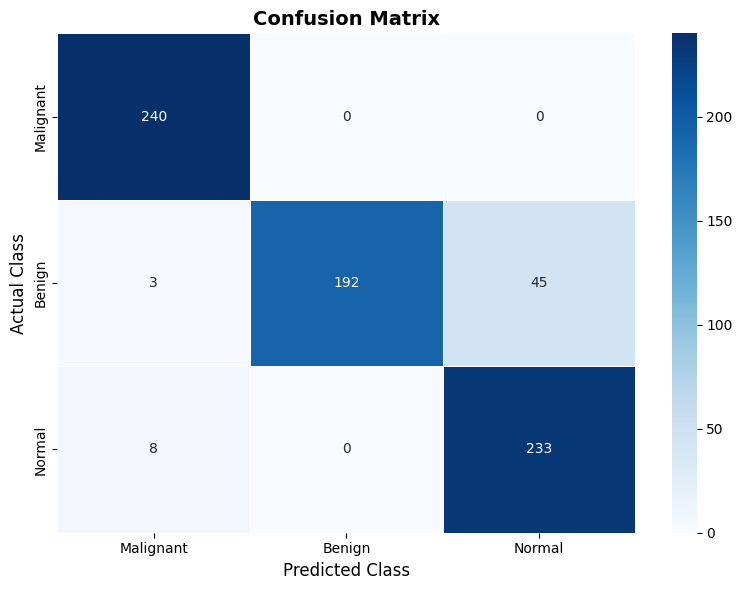


Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.96      1.00      0.98       240
      Benign       1.00      0.80      0.89       240
      Normal       0.84      0.97      0.90       241

    accuracy                           0.92       721
   macro avg       0.93      0.92      0.92       721
weighted avg       0.93      0.92      0.92       721



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

class_names = ['Malignant', 'Benign', 'Normal']

# Get all predictions on validation set
val_data.reset()
y_pred_probs = model.predict(val_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class',    fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung-cancer-dataset/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print("=" * 55)
print(classification_report(y_true, y_pred,
      target_names=class_names))

# **SAVE THE TRAINED MODEL**

In [ ]:
save_path = '/content/drive/MyDrive/lung-cancer-dataset/lung_cancer_classifier.keras'
model.save(save_path)

print(f"Model saved successfully!")
print(f"Location : {save_path}")
print(f"\nTo load later use:")
print(f"  model = tf.keras.models.load_model('{save_path}')")

Model saved successfully!
Location : /content/drive/MyDrive/lung-cancer-dataset/lung_cancer_classifier.keras

To load later use:
  model = tf.keras.models.load_model('/content/drive/MyDrive/lung-cancer-dataset/lung_cancer_classifier.keras')


# **TEST ON A NEW IMAGE**

Upload a CT scan image to classify...


Saving Bengin case (43).jpg to Bengin case (43).jpg


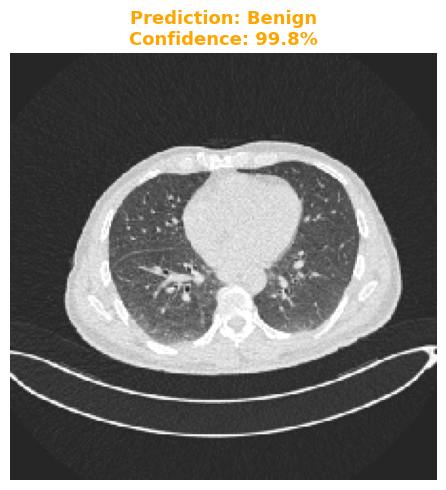


Prediction Probabilities:
  Malignant     0.0%
  Benign       █████████████████████████████ 99.8%
  Normal        0.2%

Diagnosis : BENIGN
Confidence: 99.8%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Upload a CT scan image to classify...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Prepare image exactly as during training
img       = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Get prediction
predictions  = model.predict(img_array, verbose=0)[0]
class_names  = ['Malignant', 'Benign', 'Normal']
predicted_idx = np.argmax(predictions)
predicted_class = class_names[predicted_idx]
confidence      = predictions[predicted_idx]

# Display image with result
plt.figure(figsize=(6, 5))
img_display = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img_display)
plt.title(f'Prediction: {predicted_class}\nConfidence: {confidence*100:.1f}%',
          fontsize=13, fontweight='bold',
          color='red' if predicted_class == 'Malignant' else
                'orange' if predicted_class == 'Benign' else 'green')
plt.axis('off')
plt.tight_layout()
plt.show()

# Print all class probabilities
print("\nPrediction Probabilities:")
print("=" * 35)
for cls, prob in zip(class_names, predictions):
    bar = "█" * int(prob * 30)
    print(f"  {cls:12} {bar} {prob*100:.1f}%")
print("=" * 35)
print(f"\nDiagnosis : {predicted_class.upper()}")
print(f"Confidence: {confidence*100:.1f}%")

# **Install Streamlit & ngrok**

In [ ]:
!pip install streamlit pyngrok -q
print("✅ Streamlit and ngrok installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 133.1 MB/s eta 0:00:00
✅ Streamlit and ngrok installed!


In [ ]:
import os

folder = "/content/drive/MyDrive/lung-cancer-dataset"
print("Files in your Drive folder:")
for f in os.listdir(folder):
    print(f"  📄 {f}")

Files in your Drive folder:
  📄 Normal cases
  📄 Benign cases
  📄 Malignant cases
  📄 lung_cancer_dataset.csv
  📄 lung_cancer_resnet_model.h5
  📄 training_results.png
  📄 confusion_matrix.png
  📄 lung_cancer_classifier.keras
  📄 dashboard_clinical_model.pkl
  📄 dashboard_image_model.keras


In [ ]:
# ── Reload Image Model ──────────────────────
import tensorflow as tf
import pandas as pd
import pickle
from sklearn.ensemble import GradientBoostingClassifier

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/lung-cancer-dataset/lung_cancer_classifier.keras'
)
print("✅ Image model loaded!")

✅ Image model loaded!


In [ ]:
# ── Retrain Clinical Model ───────────────────
import pandas as pd
import pickle
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

csv_path = "/content/drive/MyDrive/lung-cancer-dataset/lung_cancer_dataset.csv"
df = pd.read_csv(csv_path)

df = df.drop(columns=[
    'Patient_ID', 'Diagnosis_Date', 'Diagnosis_Year',
    'Country', 'WHO_Region', 'NSCLC_Subtype',
    'Treatment', 'Survival_Months',
    'Diagnosis_Method', 'Cancer_Type'
])

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == object:
        df[col] = le.fit_transform(df[col])

X = df.drop(columns=['Survived'])
y = df['Survived']

df_combined = pd.concat([X, y], axis=1)
majority    = df_combined[df_combined['Survived'] == 0]
minority    = df_combined[df_combined['Survived'] == 1]
minority_up = resample(minority, replace=True,
                       n_samples=len(majority), random_state=42)
df_balanced = pd.concat([majority, minority_up])

X = df_balanced.drop(columns=['Survived'])
y = df_balanced['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clinical_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, random_state=42
)
clinical_model.fit(X_train, y_train)
print("✅ Clinical model trained!")

# Save immediately
with open('/content/drive/MyDrive/lung-cancer-dataset/dashboard_clinical_model.pkl', 'wb') as f:
    pickle.dump(clinical_model, f)
print("✅ Clinical model saved to Drive!")

✅ Clinical model trained!
✅ Clinical model saved to Drive!


# Save model for **Streamlit**

In [ ]:
import pickle

# Save image model
model.save('/content/drive/MyDrive/lung-cancer-dataset/dashboard_image_model.keras')

# Save clinical model
with open('/content/drive/MyDrive/lung-cancer-dataset/dashboard_clinical_model.pkl', 'wb') as f:
    pickle.dump(clinical_model, f)

print("✅ Both models saved for dashboard!")

✅ Both models saved for dashboard!


# **Streamlit App**

In [ ]:
app_code = '''
import streamlit as st
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image
import pickle
import pandas as pd

# ── Page Config ─────────────────────────────
st.set_page_config(
    page_title="Lung Cancer AI Diagnosis",
    page_icon="🫁",
    layout="wide"
)

# ── Custom CSS ───────────────────────────────
st.markdown("""
<style>
    .main-title {
        text-align: center;
        color: #1F4E79;
        font-size: 2.2em;
        font-weight: bold;
        margin-bottom: 0px;
    }
    .sub-title {
        text-align: center;
        color: #2E75B6;
        font-size: 1.1em;
        margin-bottom: 30px;
    }
    .result-malignant {
    background-color: #7b0000;
    border-left: 5px solid #FF0000;
    padding: 20px;
    border-radius: 8px;
    margin: 10px 0;
    color: white;
    }
    .result-normal {
    background-color: #1a472a;
    border-left: 5px solid #00FF00;
    padding: 20px;
    border-radius: 8px;
    margin: 10px 0;
    color: white;
    }
    .metric-box {
        background-color: #F0F7FF;
        padding: 15px;
        border-radius: 8px;
        text-align: center;
        margin: 5px;
    }
</style>
""", unsafe_allow_html=True)

# ── Load Models ──────────────────────────────
@st.cache_resource
def load_models():
    image_model = tf.keras.models.load_model(
        "/content/drive/MyDrive/lung-cancer-dataset/dashboard_image_model.keras"
    )
    with open("/content/drive/MyDrive/lung-cancer-dataset/dashboard_clinical_model.pkl", "rb") as f:
        clinical_model = pickle.load(f)
    return image_model, clinical_model

image_model, clinical_model = load_models()

# ── Header ───────────────────────────────────
st.markdown("<div class=\'main-title\'>🫁 Lung Cancer AI Diagnosis System</div>", unsafe_allow_html=True)
st.markdown("<div class=\'sub-title\'>Multi-Modal AI — CT Scan + Clinical Data Fusion | Internship-1</div>", unsafe_allow_html=True)
st.markdown("---")

# ── Model Performance Metrics ────────────────
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("Image Model Accuracy", "~90%", "ResNet50")
with col2:
    st.metric("Clinical Model Accuracy", "84.96%", "Gradient Boosting")
with col3:
    st.metric("Dataset Size", "3,452", "CT Scan Images")
with col4:
    st.metric("Fusion Weight", "50 / 50", "Equal Weighted")

st.markdown("---")

# ── Main Layout ──────────────────────────────
left_col, right_col = st.columns([1, 1])

# ── Left Column: CT Scan Upload ──────────────
with left_col:
    st.subheader("🖼️ Step 1: Upload CT Scan Image")
    uploaded_file = st.file_uploader(
        "Choose a CT scan image",
        type=["jpg", "jpeg", "png"],
        help="Upload a lung CT scan image for analysis"
    )

    if uploaded_file:
        img = Image.open(uploaded_file).convert("RGB")
        st.image(img, caption="Uploaded CT Scan", use_column_width=True)

# ── Right Column: Patient Details ────────────
with right_col:
    st.subheader("🏥 Step 2: Enter Patient Details")

    p_age     = st.slider("Age",                    20, 90, 55)
    p_gender  = st.selectbox("Gender",              ["Male", "Female"])
    p_smoking = st.selectbox("Smoking Status",      ["Never Smoked", "Former Smoker", "Current Smoker"])
    p_cigs    = st.slider("Cigarettes Per Day",      0, 60, 10)
    p_years   = st.slider("Years Smoking",           0, 50, 15)
    p_bmi     = st.slider("BMI",                    15.0, 45.0, 24.5)
    p_genetic = st.selectbox("Genetic Mutation",    ["No", "Yes"])
    p_stage   = st.selectbox("Cancer Stage",        ["Stage I", "Stage II", "Stage III", "Stage IV"])
    p_tumor   = st.slider("Tumor Size (cm)",         0.0, 10.0, 2.5)
    p_cough   = st.selectbox("Coughing",            ["No", "Yes"])
    p_chest   = st.selectbox("Chest Pain",          ["No", "Yes"])
    p_breath  = st.selectbox("Shortness of Breath", ["No", "Yes"])
    p_fatigue = st.selectbox("Fatigue",             ["No", "Yes"])
    p_meta    = st.selectbox("Metastasis",          ["No", "Yes"])

# ── Diagnose Button ──────────────────────────
st.markdown("---")
diagnose_btn = st.button("🔍 Run Diagnosis", type="primary", use_container_width=True)

if diagnose_btn:
    if uploaded_file is None:
        st.error("Please upload a CT scan image first!")
    else:
        with st.spinner("Analyzing CT scan and clinical data..."):

            # ── Image Prediction ─────────────
            img_resized  = img.resize((224, 224))
            img_array    = np.array(img_resized, dtype=np.float32)
            img_array    = preprocess_input(img_array)
            img_array    = np.expand_dims(img_array, axis=0)
            img_preds    = image_model.predict(img_array, verbose=0)[0]
            class_names  = ["Malignant", "Benign", "Normal"]
            img_scores   = dict(zip(class_names, img_preds))

            # ── Clinical Prediction ──────────
            smoking_map = {"Never Smoked": 0, "Former Smoker": 1, "Current Smoker": 2}
            yes_no_map  = {"No": 0, "Yes": 1}
            stage_map   = {"Stage I": 1, "Stage II": 2, "Stage III": 3, "Stage IV": 4}

            patient = {
                "Age":                    p_age,
                "Gender":                 0 if p_gender == "Female" else 1,
                "Smoking_Status":         smoking_map[p_smoking],
                "Cigarettes_Per_Day":     p_cigs,
                "Years_Smoking":          p_years,
                "Secondhand_Smoke":       0,
                "Family_History":         0,
                "Occupational_Hazard":    0,
                "Air_Pollution_Exposure": 1,
                "Alcohol_Use":            0,
                "BMI":                    p_bmi,
                "Exercise_Frequency":     1,
                "Chronic_Lung_Disease":   0,
                "Asbestos_Exposure":      0,
                "Radon_Exposure":         0,
                "Previous_Cancer_History":0,
                "Genetic_Mutation":       yes_no_map[p_genetic],
                "Coughing":               yes_no_map[p_cough],
                "Shortness_of_Breath":    yes_no_map[p_breath],
                "Chest_Pain":             yes_no_map[p_chest],
                "Coughing_Blood":         0,
                "Fatigue":                yes_no_map[p_fatigue],
                "Weight_Loss":            0,
                "Wheezing":               0,
                "Recurrent_Infections":   0,
                "Swallowing_Difficulty":  0,
                "Finger_Clubbing":        0,
                "Cancer_Stage":           stage_map[p_stage],
                "Tumor_Size_cm":          p_tumor,
                "Metastasis":             yes_no_map[p_meta],
            }

            patient_df   = pd.DataFrame([patient])
            clin_proba   = clinical_model.predict_proba(patient_df)[0]
            clin_cancer  = float(clin_proba[1])
            clin_normal  = float(clin_proba[0])

            # ── Fusion ───────────────────────
            final_scores = {}
            for c in class_names:
                img_s  = float(img_scores.get(c, 0))
                clin_s = clin_cancer if c == "Malignant" else clin_normal if c == "Normal" else 0.1
                final_scores[c] = round((0.5 * img_s) + (0.5 * clin_s), 3)

            diagnosis  = max(final_scores, key=final_scores.get)
            confidence = final_scores[diagnosis]

        # ── Display Results ──────────────────
        st.markdown("---")
        st.subheader("🔬 Diagnosis Results")

        res_col1, res_col2 = st.columns([1, 1])

        with res_col1:
            if diagnosis == "Malignant":
                st.markdown(f"""
                <div class="result-malignant">
                    <h2>🔴 MALIGNANT</h2>
                    <h3>Confidence: {confidence*100:.1f}%</h3>
                    <p>⚠️ Immediate oncologist consultation advised</p>
                </div>
                """, unsafe_allow_html=True)
            else:
                st.markdown(f"""
                <div class="result-normal">
                    <h2>🟢 {diagnosis.upper()}</h2>
                    <h3>Confidence: {confidence*100:.1f}%</h3>
                    <p>✅ Routine annual screening advised</p>
                </div>
                """, unsafe_allow_html=True)

            st.markdown("**⚕️ Note:** This tool is for research purposes only.")

        with res_col2:
            st.markdown("**Confidence Breakdown:**")
            for cls, score in final_scores.items():
                color = "red" if cls == "Malignant" else "green" if cls == "Normal" else "orange"
                st.markdown(f"**{cls}**")
                st.progress(float(score))
                st.markdown(f"`{score*100:.1f}%`")

            st.markdown("---")
            st.markdown("**Model Contributions:**")
            img_mal = float(img_scores.get("Malignant", 0))
            st.markdown(f"🫁 Image Model  → Malignant: `{img_mal*100:.1f}%`")
            st.markdown(f"🏥 Clinical Model → High Risk: `{clin_cancer*100:.1f}%`")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("✅ Streamlit app created!")

✅ Streamlit app created!


# **Save app.py to Drive**

In [ ]:
!cp /content/app.py /content/drive/MyDrive/lung-cancer-dataset/app.py
print("✅ app.py saved to Drive!")

✅ app.py saved to Drive!


# **Launch Streamlit Dashboard**

In [1]:
# Step 1: Install required packages
!pip install streamlit pyngrok -q

# Step 2: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 3: Load models
import tensorflow as tf
import pickle

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/lung-cancer-dataset/dashboard_image_model.keras'
)
print("✅ Image model loaded!")

with open('/content/drive/MyDrive/lung-cancer-dataset/dashboard_clinical_model.pkl', 'rb') as f:
    clinical_model = pickle.load(f)
print("✅ Clinical model loaded!")

# Step 4: Save app.py from Drive if it exists
# otherwise recreate it
import os
app_drive_path = '/content/drive/MyDrive/lung-cancer-dataset/app.py'
if os.path.exists(app_drive_path):
    !cp /content/drive/MyDrive/lung-cancer-dataset/app.py /content/app.py
    print("✅ app.py loaded from Drive!")
else:
    print("⚠️ app.py not found in Drive — please run Cell 14 first!")

# Step 5: Launch dashboard
from pyngrok import ngrok
import subprocess
import time

ngrok.set_auth_token("3B740VW0eOdXLhudobF9H3L7vzQ_86opMLbTL2EE6PPZypFM1")
!kill -9 $(lsof -t -i:8501) 2>/dev/null || true

process = subprocess.Popen(
    ['streamlit', 'run', '/content/app.py',
     '--server.port', '8501',
     '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

public_url = ngrok.connect(8501)
print("="*50)
print("✅ Dashboard is LIVE!")
print(f"🌐 URL: {public_url}")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 130.9 MB/s eta 0:00:00
Mounted at /content/drive
✅ Image model loaded!
✅ Clinical model loaded!
✅ app.py loaded from Drive!
✅ Dashboard is LIVE!
🌐 URL: NgrokTunnel: "https://superwise-preston-compulsively.ngrok-free.dev" -> "http://localhost:8501"
